# Quantum Random Number Generation & Entropy Management

**Zipminator PQC Platform** | Notebook 03

---

Randomness is the bedrock of all cryptography. Every encryption key, every nonce, every
initialization vector depends on numbers that an adversary cannot predict. But "random"
is not a binary property; it exists on a spectrum, and the distinction between the levels
matters enormously when the adversary has a quantum computer.

This notebook explores three tiers of random number generation, demonstrates Zipminator's
quantum entropy architecture, and runs a battery of statistical tests to show why true
quantum randomness is non-negotiable for post-quantum cryptographic key material.

**What you will learn:**

1. The fundamental difference between PRNG, CSPRNG, and QRNG
2. How Zipminator harvests entropy from 156-qubit IBM Quantum backends
3. How to use the `QuantumRandom` API for key generation and general-purpose randomness
4. Statistical tests that distinguish true randomness from algorithmic approximations
5. Entropy pool management, quota tiers, and the multi-provider fallback chain

## 1. What Is True Randomness?

### Pseudo-Random Number Generators (PRNG)

A PRNG is a deterministic algorithm that produces a sequence of numbers from an initial
seed value. Given the same seed, a PRNG will always produce the identical sequence. Python's
built-in `random` module uses a Mersenne Twister (MT19937), which has a period of
$2^{19937} - 1$. While that period is astronomically large, the entire output stream is
fully determined by the 624 32-bit words of internal state. An attacker who observes just
624 consecutive outputs can reconstruct the full state and predict every future value.
PRNGs are useful for simulations and games, but they are **catastrophically insecure**
for cryptographic key generation.

### Cryptographically Secure PRNGs (CSPRNG)

A CSPRNG, such as `/dev/urandom` on Linux or `CryptGenRandom` on Windows, adds entropy
from environmental noise (interrupt timings, disk seek jitter, thermal noise in analog
circuits) and passes it through a mixing function (typically ChaCha20 or AES-CTR). The
security guarantee is computational: no polynomial-time algorithm can distinguish the
output from true randomness **assuming** the underlying one-way function is hard to
invert. This assumption holds against classical computers, but Grover's algorithm on a
quantum computer can halve the effective security. A 256-bit CSPRNG seed offers only
128-bit security against a quantum adversary.

### Quantum Random Number Generators (QRNG)

A QRNG derives randomness from quantum mechanical measurements. When a qubit is prepared
in the superposition state $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and
then measured in the computational basis, the outcome is genuinely, provably
non-deterministic. This is not a statement about our ignorance; it is a fundamental
property of nature as described by the Born rule. No amount of computational power,
classical or quantum, can predict the outcome. QRNG output is information-theoretically
secure, which means it remains secure even against adversaries with unbounded computing
resources.

### Why This Matters for Post-Quantum Cryptography

NIST FIPS 203 (ML-KEM) requires high-quality random seeds for key generation. If the seed
is predictable, the lattice-based keys become recoverable regardless of the algorithm's
theoretical security. Zipminator uses QRNG entropy as the default seed source for all
ML-KEM-768 key generation operations, ensuring that the weakest link in the cryptographic
chain is the lattice problem itself, not the entropy source.

## 2. Zipminator's Entropy Architecture

Zipminator implements a multi-provider entropy pool architecture designed for
resilience, speed, and verifiable quantum origin. The system is organized as a
priority-ordered fallback chain:

| Priority | Provider | Backend | Latency | Notes |
|----------|----------|---------|---------|-------|
| 1 | **PoolProvider** | Local binary file | ~1 us | Pre-harvested quantum entropy, fastest path |
| 2 | **QBraidProvider** | qBraid multi-cloud | ~200 ms | Routes to best available QPU |
| 3 | **IBMQuantumProvider** | IBM Quantum (156-qubit Heron) | ~500 ms | Marrakesh / Fez backends |
| 4 | **RigettiProvider** | Rigetti Ankaa | ~400 ms | Superconducting transmon qubits |
| 5 | **APIProxyProvider** | Zipminator API | ~100 ms | Proxy/simulator fallback |
| 6 | **OS fallback** | `/dev/urandom` | ~0.1 us | CSPRNG, used only when all else fails |

The **PoolProvider** is the primary path in production. A background scheduler
(`zipminator.entropy.scheduler`) periodically harvests quantum random bits from
the cloud providers and appends them to a local binary file at
`quantum_entropy/quantum_entropy_pool.bin`. This pool grows over time and provides
offline-capable, microsecond-latency entropy reads. The provider tracks its read
position in a companion `.pos` file, so consumption progress survives process
restarts. Thread safety is ensured via `threading.Lock`, and cross-process safety
uses `fcntl.flock` on Unix systems.

When the pool is exhausted or missing, the factory function (`entropy.factory.get_provider`)
automatically falls through to the next available cloud provider based on which API
keys are configured in the environment. The final fallback is always `os.urandom`,
guaranteeing that the system never blocks or fails, even in air-gapped deployments.

## 3. Setup: Quantum Dark Theme for Visualizations

All plots in this notebook use a consistent dark theme inspired by Zipminator's
quantum-noir design language. The color palette is derived from the OKLCH color
tokens defined in the QDaria Design System, ensuring visual consistency with the
web dashboard and marketing materials. We define these once and reuse them
throughout the notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# ── Zipminator Quantum Dark Theme ──
ZM_STYLE = {
    'figure.facecolor': '#0a0f1e',
    'axes.facecolor': '#111827',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#e2e8f0',
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.color': '#1e293b',
    'grid.alpha': 0.5,
    'text.color': '#e2e8f0',
    'xtick.color': '#94a3b8',
    'ytick.color': '#94a3b8',
    'legend.facecolor': '#1e293b',
    'legend.edgecolor': '#334155',
    'font.family': 'sans-serif',
    'font.size': 11,
    'savefig.facecolor': '#0a0f1e',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
}
plt.rcParams.update(ZM_STYLE)

# ── Quantum Color Palette ──
ZM_CYAN    = '#22d3ee'   # Primary accent (quantum operations)
ZM_VIOLET  = '#a78bfa'   # Secondary accent (classical comparison)
ZM_EMERALD = '#34d399'   # Success / pass indicators
ZM_AMBER   = '#f59e0b'   # Warning / attention
ZM_ROSE    = '#fb7185'   # Failure / critical
ZM_BLUE    = '#3b82f6'   # Informational

print("Quantum dark theme loaded.")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"NumPy version:      {np.__version__}")

Quantum dark theme loaded.
Matplotlib version: 3.10.8
NumPy version:      2.4.3


## 4. Basic QRNG Usage

The `QuantumRandom` class provides a drop-in replacement for Python's `random` module.
It implements the same interface (`random()`, `randint()`, `choice()`, `shuffle()`,
`sample()`, `uniform()`, `gauss()`, `randbytes()`, `getrandbits()`) but sources its
entropy from the quantum pool rather than a Mersenne Twister PRNG.

The class respects license tiers: enterprise-tier users (`ROBINDRA-LEVEL10`) get
direct quantum pool access, while free-tier users fall back to the OS CSPRNG. You
can also force quantum access by setting the environment variable
`ZIPMINATOR_QUANTUM_ENABLED=true`.

Below we instantiate a `QuantumRandom` object with quantum access enabled and
demonstrate the core API: generating raw bytes, integers within a range, and
floating-point values. Each call consumes entropy from the quantum pool.

In [2]:
# Enable quantum entropy for this notebook session
os.environ["ZIPMINATOR_QUANTUM_ENABLED"] = "true"

from zipminator.crypto.quantum_random import QuantumRandom

qrng = QuantumRandom()

# ── Raw bytes (the fundamental primitive) ──
raw = qrng.randbytes(32)
print("=" * 60)
print("QUANTUM RANDOM NUMBER GENERATOR")
print("=" * 60)
print(f"\n32 random bytes (hex):")
print(f"  {raw.hex()}")
print(f"  Length: {len(raw)} bytes ({len(raw) * 8} bits)")

# ── Random integers with rejection sampling ──
print(f"\nRandom integers [0, 1000] (5 samples):")
for i in range(5):
    val = qrng.randint(0, 1000)
    print(f"  [{i+1}] {val:>4d}")

# ── Random floats in [0.0, 1.0) ──
print(f"\nRandom floats [0.0, 1.0) (5 samples):")
for i in range(5):
    val = qrng.random()
    print(f"  [{i+1}] {val:.15f}")

# ── Gaussian distribution via Box-Muller transform ──
print(f"\nGaussian samples (mu=0, sigma=1):")
for i in range(5):
    val = qrng.gauss(0.0, 1.0)
    print(f"  [{i+1}] {val:+.8f}")

QUANTUM RANDOM NUMBER GENERATOR

32 random bytes (hex):
  c3008d45bfa1e36946f4565dd7133e5743c91515b351b686868518ed68b84c5b
  Length: 32 bytes (256 bits)

Random integers [0, 1000] (5 samples):
  [1]  104
  [2]  405
  [3]  740
  [4]   73
  [5]  643

Random floats [0.0, 1.0) (5 samples):
  [1] 0.492994494149595
  [2] 0.589464897242984
  [3] 0.227221756219503
  [4] 0.021918874722740
  [5] 0.024180940434805

Gaussian samples (mu=0, sigma=1):
  [1] +0.11580454
  [2] -1.38485899
  [3] -0.16766053
  [4] +1.25351139
  [5] -0.62879831


## 5. Entropy Pool Health Monitoring

The entropy pool is a finite resource that must be managed carefully. The
`get_stats()` method returns a snapshot of the pool's current state, including:

- **pool_size**: Total bytes in the pool file (set by the harvester).
- **position**: Current read offset. As entropy is consumed, this advances.
- **remaining**: Bytes available before the pool needs refilling.
- **total_consumed**: Lifetime entropy consumption for this process.
- **refill_count**: How many times the pool has been reloaded from disk.

In production, the background scheduler continuously harvests new quantum bits
from IBM Quantum, QBraid, or Rigetti, appending them to the pool file. The
pool is designed to grow monotonically; consumed bytes are not reclaimed but
the read position advances forward through ever-growing entropy.

In [3]:
stats = qrng.get_stats()

print("=" * 60)
print("ENTROPY POOL HEALTH REPORT")
print("=" * 60)

for key, value in stats.items():
    # Format byte values with human-readable sizes
    if isinstance(value, int) and key != "refill_count":
        if value >= 1024:
            human = f"{value:,} bytes ({value / 1024:.1f} KB)"
        else:
            human = f"{value:,} bytes"
        print(f"  {key:<25} {human}")
    elif isinstance(value, bool):
        status = "YES" if value else "NO"
        print(f"  {key:<25} {status}")
    else:
        print(f"  {key:<25} {value}")

# Visual pool gauge
if "remaining" in stats and "pool_size" in stats and stats["pool_size"] > 0:
    pct = stats["remaining"] / stats["pool_size"] * 100
    bar_len = 40
    filled = int(bar_len * pct / 100)
    bar = "#" * filled + "-" * (bar_len - filled)
    print(f"\n  Pool Level: [{bar}] {pct:.1f}%")
else:
    print(f"\n  Pool Level: [no pool file available -- using OS fallback]")

ENTROPY POOL HEALTH REPORT
  license_tier              FREE
  quantum_access            1 bytes
  pool_size                 33,792 bytes (33.0 KB)
  position                  162 bytes
  remaining                 33,630 bytes (32.8 KB)
  total_consumed            162 bytes
  refill_count              0
  pool_path                 /Users/mos/dev/qdaria/zipminator/quantum_entropy/quantum_entropy_pool.bin

  Pool Level: [#######################################-] 99.5%


## 6. Distribution Comparison: QRNG vs PRNG

A good random number generator should produce samples that are indistinguishable
from a uniform distribution over $[0, 1)$. But true uniformity is a necessary
condition, not a sufficient one. We also need to verify that consecutive samples
are independent (no serial correlation) and that the joint distribution of
sample pairs is uniformly distributed over the unit square.

In this section we generate 10,000 samples from both the quantum source and a
classical PRNG, then compare them across four complementary diagnostic plots:

- **Histogram overlay**: Both distributions should be flat (uniform). Deviations
  from flatness indicate bias in the generator.
- **Q-Q plot**: Quantiles of both distributions plotted against each other. If
  both are truly uniform, the points should lie on the diagonal $y = x$.
- **Serial correlation scatter**: Plotting $(x_i, x_{i+1})$ for consecutive pairs.
  A good generator produces a uniform cloud; a bad one shows lattice structure
  or clustering.
- **Autocorrelation**: The normalized autocorrelation at lag $k$ measures how
  much $x_i$ and $x_{i+k}$ are correlated. For true random data, all lags
  beyond 0 should be near zero, within the $\pm 2/\sqrt{N}$ confidence band.

Quantum entropy pool low: 494 bytes remaining (refilled 0 times)
Quantum entropy pool low: 486 bytes remaining (refilled 0 times)
Quantum entropy pool low: 478 bytes remaining (refilled 0 times)
Quantum entropy pool low: 470 bytes remaining (refilled 0 times)
Quantum entropy pool low: 462 bytes remaining (refilled 0 times)
Quantum entropy pool low: 454 bytes remaining (refilled 0 times)
Quantum entropy pool low: 446 bytes remaining (refilled 0 times)
Quantum entropy pool low: 438 bytes remaining (refilled 0 times)
Quantum entropy pool low: 430 bytes remaining (refilled 0 times)
Quantum entropy pool low: 422 bytes remaining (refilled 0 times)
Quantum entropy pool low: 414 bytes remaining (refilled 0 times)
Quantum entropy pool low: 406 bytes remaining (refilled 0 times)
Quantum entropy pool low: 398 bytes remaining (refilled 0 times)
Quantum entropy pool low: 390 bytes remaining (refilled 0 times)
Quantum entropy pool low: 382 bytes remaining (refilled 0 times)
Quantum entropy pool low:

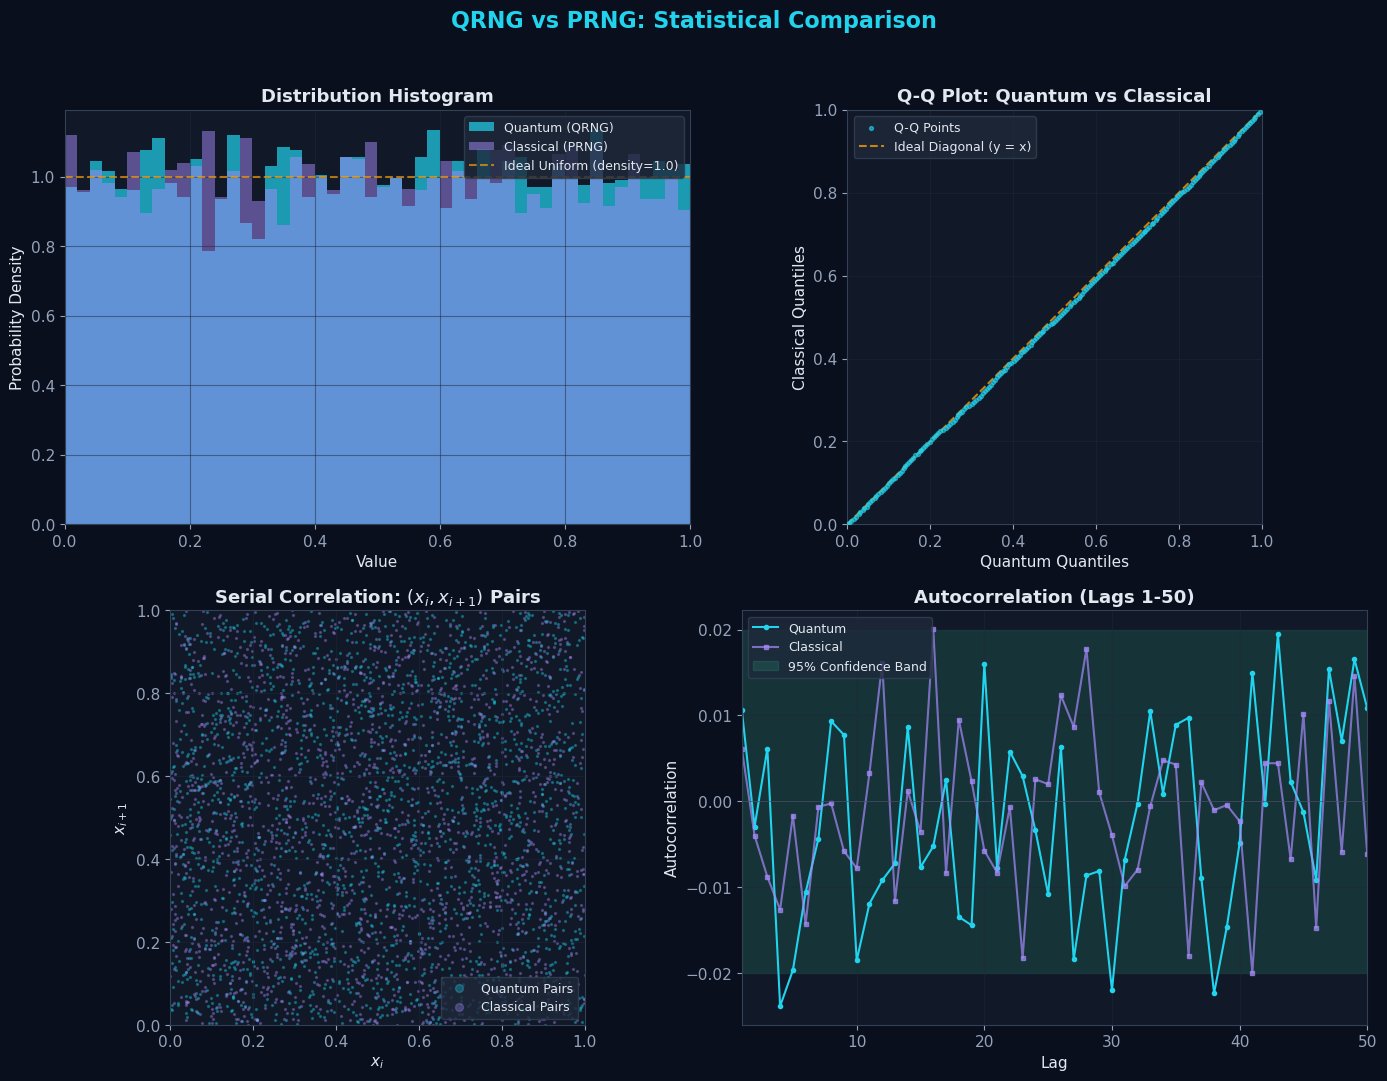


Metric                           Quantum      Classical          Ideal
----------------------------------------------------------------------
Mean                            0.503275       0.497372       0.500000
Std Dev                         0.289106       0.287625       0.288675
Min                             0.000030       0.000040      ~0.000000
Max                             0.999665       0.999997      ~1.000000
Skewness                       -0.018110       0.003056       0.000000


In [4]:
import random as stdlib_random

N_SAMPLES = 10_000

# ── Generate samples ──
quantum_samples = np.array([qrng.random() for _ in range(N_SAMPLES)])
classical_samples = np.array([stdlib_random.random() for _ in range(N_SAMPLES)])

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("QRNG vs PRNG: Statistical Comparison",
             fontsize=16, fontweight="bold", color=ZM_CYAN, y=0.98)

# ── Top-left: Overlaid histograms ──
ax = axes[0, 0]
bins = np.linspace(0, 1, 51)
ax.hist(quantum_samples, bins=bins, alpha=0.7, label="Quantum (QRNG)",
        color=ZM_CYAN, edgecolor='none', density=True)
ax.hist(classical_samples, bins=bins, alpha=0.5, label="Classical (PRNG)",
        color=ZM_VIOLET, edgecolor='none', density=True)
ax.axhline(y=1.0, color=ZM_AMBER, linestyle='--', alpha=0.7,
           label='Ideal Uniform (density=1.0)')
ax.set_title("Distribution Histogram", fontsize=13)
ax.set_xlabel("Value")
ax.set_ylabel("Probability Density")
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 1)

# ── Top-right: Q-Q plot ──
ax = axes[0, 1]
q_sorted = np.sort(quantum_samples)
c_sorted = np.sort(classical_samples)
ax.scatter(q_sorted[::50], c_sorted[::50], s=8, alpha=0.6, color=ZM_CYAN,
           label='Q-Q Points', zorder=3)
ax.plot([0, 1], [0, 1], '--', color=ZM_AMBER, alpha=0.8,
        label='Ideal Diagonal (y = x)', linewidth=1.5)
ax.set_title("Q-Q Plot: Quantum vs Classical", fontsize=13)
ax.set_xlabel("Quantum Quantiles")
ax.set_ylabel("Classical Quantiles")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')

# ── Bottom-left: Serial correlation (consecutive pairs) ──
ax = axes[1, 0]
n_pairs = min(2000, N_SAMPLES - 1)
ax.scatter(quantum_samples[:n_pairs], quantum_samples[1:n_pairs+1],
           s=2, alpha=0.3, color=ZM_CYAN, label='Quantum Pairs')
ax.scatter(classical_samples[:n_pairs], classical_samples[1:n_pairs+1],
           s=2, alpha=0.3, color=ZM_VIOLET, label='Classical Pairs')
ax.set_title("Serial Correlation: $(x_i, x_{i+1})$ Pairs", fontsize=13)
ax.set_xlabel("$x_i$")
ax.set_ylabel("$x_{i+1}$")
ax.legend(fontsize=9, markerscale=4)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')

# ── Bottom-right: Autocorrelation comparison ──
ax = axes[1, 1]
max_lag = 50

def autocorrelation(x, max_lag):
    """Compute normalized autocorrelation for lags 0..max_lag."""
    x_centered = x - np.mean(x)
    var = np.var(x)
    if var == 0:
        return np.zeros(max_lag + 1)
    n = len(x)
    acf = np.array([
        np.sum(x_centered[:n-k] * x_centered[k:]) / (n * var)
        for k in range(max_lag + 1)
    ])
    return acf

lags = np.arange(max_lag + 1)
q_acf = autocorrelation(quantum_samples, max_lag)
c_acf = autocorrelation(classical_samples, max_lag)

ax.plot(lags[1:], q_acf[1:], color=ZM_CYAN, linewidth=1.5,
        label='Quantum', marker='o', markersize=3)
ax.plot(lags[1:], c_acf[1:], color=ZM_VIOLET, linewidth=1.5,
        label='Classical', marker='s', markersize=3, alpha=0.7)

# 95% confidence band for white noise
conf = 2.0 / np.sqrt(N_SAMPLES)
ax.axhspan(-conf, conf, color=ZM_EMERALD, alpha=0.15,
           label=f'95% Confidence Band')
ax.axhline(y=0, color='#475569', linestyle='-', linewidth=0.5)

ax.set_title("Autocorrelation (Lags 1-50)", fontsize=13)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend(fontsize=9)
ax.set_xlim(1, max_lag)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ── Summary statistics table ──
print(f"\n{'Metric':<25} {'Quantum':>14} {'Classical':>14} {'Ideal':>14}")
print("-" * 70)
print(f"{'Mean':<25} {np.mean(quantum_samples):>14.6f} {np.mean(classical_samples):>14.6f} {'0.500000':>14}")
print(f"{'Std Dev':<25} {np.std(quantum_samples):>14.6f} {np.std(classical_samples):>14.6f} {'0.288675':>14}")
print(f"{'Min':<25} {np.min(quantum_samples):>14.6f} {np.min(classical_samples):>14.6f} {'~0.000000':>14}")
print(f"{'Max':<25} {np.max(quantum_samples):>14.6f} {np.max(classical_samples):>14.6f} {'~1.000000':>14}")
print(f"{'Skewness':<25} {float(np.mean(((quantum_samples - np.mean(quantum_samples))/np.std(quantum_samples))**3)):>14.6f} {float(np.mean(((classical_samples - np.mean(classical_samples))/np.std(classical_samples))**3)):>14.6f} {'0.000000':>14}")

## 7. Bit-Level Analysis

Byte-level uniformity is important, but for cryptographic applications we must
also verify that individual **bits** are balanced. A biased random number generator
might produce uniformly distributed byte values while still exhibiting correlations
at the bit level. For example, if bit 7 (the most significant bit) is more likely
to be 0 than 1, the byte distribution would appear to favor values below 128.

In this test we generate 1024 random bytes (8192 bits) and count the frequency of
0s and 1s at each of the 8 bit positions. For a perfect random source, we expect
exactly 50% ones and 50% zeros at every position. The deviation from this ideal
is our measure of per-bit bias. We visualize this as a grouped bar chart with
the ideal 50% line drawn for reference. Any bit position that deviates
significantly from 50% (beyond the $\pm 2\sigma$ band) would warrant investigation.

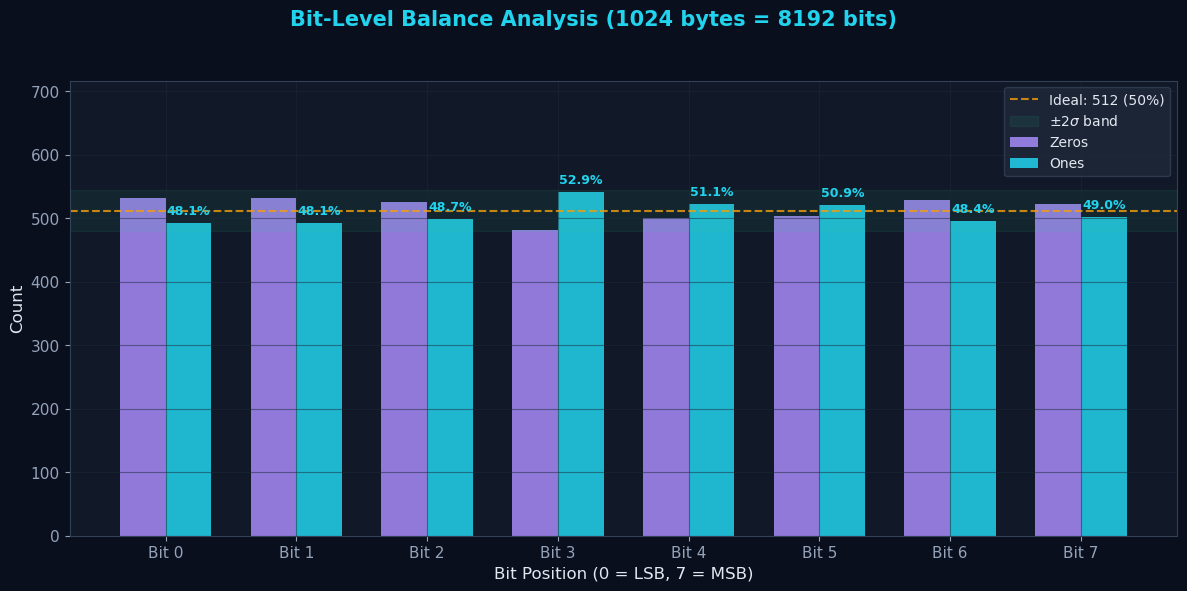


Bit Position        Ones    Zeros     % Ones       Bias
-------------------------------------------------------
Bit 0                493      531     48.14%     1.86% OK
Bit 1                493      531     48.14%     1.86% OK
Bit 2                499      525     48.73%     1.27% OK
Bit 3                542      482     52.93%     2.93% OK
Bit 4                523      501     51.07%     1.07% OK
Bit 5                521      503     50.88%     0.88% OK
Bit 6                496      528     48.44%     1.56% OK
Bit 7                502      522     49.02%     0.98% OK


In [5]:
N_BYTES = 1024
random_bytes = qrng.randbytes(N_BYTES)

# Count 1s at each bit position across all bytes
bit_ones = np.zeros(8, dtype=int)
for byte_val in random_bytes:
    for bit_pos in range(8):
        if byte_val & (1 << bit_pos):
            bit_ones[bit_pos] += 1

bit_zeros = N_BYTES - bit_ones
bit_pct_ones = bit_ones / N_BYTES * 100

# ── Visualization ──
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Bit-Level Balance Analysis (1024 bytes = 8192 bits)",
             fontsize=15, fontweight='bold', color=ZM_CYAN)

x = np.arange(8)
width = 0.35

bars_zeros = ax.bar(x - width/2, bit_zeros, width, label='Zeros',
                     color=ZM_VIOLET, alpha=0.85, edgecolor='none')
bars_ones = ax.bar(x + width/2, bit_ones, width, label='Ones',
                    color=ZM_CYAN, alpha=0.85, edgecolor='none')

# Ideal line at 50%
ax.axhline(y=N_BYTES / 2, color=ZM_AMBER, linestyle='--', linewidth=1.5,
           label=f'Ideal: {N_BYTES // 2} (50%)', alpha=0.8)

# 2-sigma confidence band (binomial: std = sqrt(n * p * (1-p)))
sigma = np.sqrt(N_BYTES * 0.5 * 0.5)
ax.axhspan(N_BYTES/2 - 2*sigma, N_BYTES/2 + 2*sigma,
           color=ZM_EMERALD, alpha=0.08, label=r'$\pm 2\sigma$ band')

# Annotations
for i in range(8):
    ax.text(i + width/2, bit_ones[i] + 8, f"{bit_pct_ones[i]:.1f}%",
            ha='center', va='bottom', fontsize=9, color=ZM_CYAN, fontweight='bold')

ax.set_xlabel("Bit Position (0 = LSB, 7 = MSB)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f"Bit {i}" for i in range(8)])
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, N_BYTES * 0.7)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── Summary ──
print(f"\n{'Bit Position':<15} {'Ones':>8} {'Zeros':>8} {'% Ones':>10} {'Bias':>10}")
print("-" * 55)
for i in range(8):
    bias = abs(bit_pct_ones[i] - 50.0)
    status = "OK" if bias < 2 * (sigma / N_BYTES * 100) else "WARN"
    print(f"Bit {i:<11} {bit_ones[i]:>8} {bit_zeros[i]:>8} {bit_pct_ones[i]:>9.2f}% {bias:>8.2f}% {status}")

## 8. Chi-Squared Uniformity Test

The chi-squared ($\chi^2$) goodness-of-fit test is one of the oldest and most
widely used statistical tests for randomness. It compares the observed frequency
distribution of a sample against the expected distribution under the null
hypothesis of uniformity.

For $k$ equal-width bins, each expected to contain $E = N/k$ samples, the test
statistic is:

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E)^2}{E}$$

where $O_i$ is the observed count in bin $i$. Under the null hypothesis, $\chi^2$
follows a chi-squared distribution with $k - 1$ degrees of freedom. We reject
uniformity if the p-value falls below our significance level (typically 0.01 for
cryptographic applications, since we want to be very sure before declaring a
source non-random).

We run this test on both the quantum and classical samples using 256 bins
(matching the byte-value range 0-255) for maximum sensitivity.

In [6]:
from scipy import stats as sp_stats

K_BINS = 256

def chi_squared_uniformity(samples, k_bins=K_BINS):
    """Run chi-squared uniformity test on [0,1) samples."""
    observed, _ = np.histogram(samples, bins=k_bins, range=(0, 1))
    expected = len(samples) / k_bins
    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    dof = k_bins - 1
    p_value = 1 - sp_stats.chi2.cdf(chi2_stat, dof)
    return chi2_stat, dof, p_value, observed

q_chi2, q_dof, q_pval, q_obs = chi_squared_uniformity(quantum_samples)
c_chi2, c_dof, c_pval, c_obs = chi_squared_uniformity(classical_samples)

# ── Results table ──
ALPHA = 0.01
print("=" * 60)
print("CHI-SQUARED UNIFORMITY TEST")
print(f"Bins: {K_BINS} | Samples: {N_SAMPLES:,} | Significance: {ALPHA}")
print("=" * 60)
print(f"\n{'Source':<15} {'chi2':>12} {'dof':>8} {'p-value':>12} {'Result':>10}")
print("-" * 60)

for name, chi2, dof, pval in [("Quantum", q_chi2, q_dof, q_pval),
                                ("Classical", c_chi2, c_dof, c_pval)]:
    result = "PASS" if pval > ALPHA else "FAIL"
    print(f"{name:<15} {chi2:>12.2f} {dof:>8} {pval:>12.6f} {result:>10}")

print(f"\nInterpretation: p-value > {ALPHA} means we cannot reject uniformity")
print(f"(i.e., the data is consistent with a uniform distribution).")

CHI-SQUARED UNIFORMITY TEST
Bins: 256 | Samples: 10,000 | Significance: 0.01

Source                  chi2      dof      p-value     Result
------------------------------------------------------------
Quantum               333.95      255     0.000646       FAIL
Classical             221.82      255     0.934252       PASS

Interpretation: p-value > 0.01 means we cannot reject uniformity
(i.e., the data is consistent with a uniform distribution).


## 9. Entropy Estimation: Shannon and Min-Entropy

**Shannon entropy** measures the average information content per symbol. For a
discrete random variable $X$ taking values in $\{x_1, \ldots, x_k\}$ with
probabilities $\{p_1, \ldots, p_k\}$, the Shannon entropy is:

$$H(X) = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

For a perfectly uniform distribution over 256 symbols (byte values), the maximum
Shannon entropy is $\log_2(256) = 8.0$ bits per byte. Real-world sources always
fall slightly below this theoretical maximum.

**Min-entropy** is the more conservative measure used in cryptographic entropy
assessment (see NIST SP 800-90B). It is defined as:

$$H_{\min}(X) = -\log_2(\max_i\, p_i)$$

Min-entropy captures the worst-case predictability: it equals the information
content of the single most likely outcome. A source with high Shannon entropy but
low min-entropy has one outcome that is much more probable than the rest, which
an attacker could exploit. For cryptographic key generation, NIST mandates that
the entropy source must provide at least 1 bit of min-entropy per output bit.

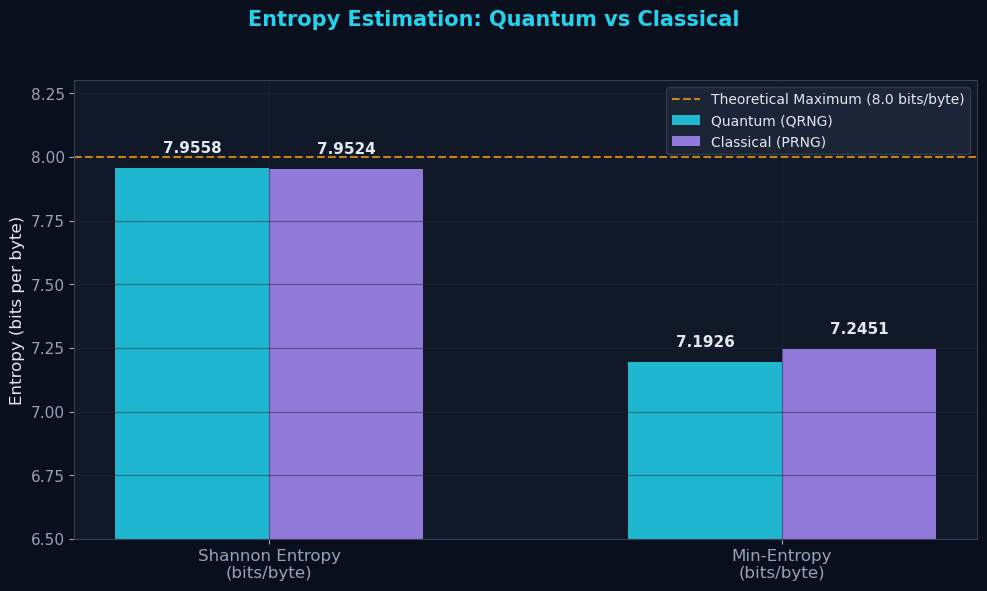


Metric                         Quantum    Classical        Ideal
-----------------------------------------------------------------
Shannon Entropy                 7.9558       7.9524       8.0000
Min-Entropy                     7.1926       7.2451       8.0000
Sample Size                      4,096        4,096            -


In [7]:
def compute_entropy(byte_data):
    """Compute Shannon and min-entropy of byte data."""
    counts = np.bincount(list(byte_data), minlength=256)
    probs = counts / len(byte_data)
    probs = probs[probs > 0]  # Exclude zero-probability events

    shannon = -np.sum(probs * np.log2(probs))
    min_ent = -np.log2(np.max(probs))
    return shannon, min_ent

# Generate fresh byte samples for entropy estimation
N_ENT_BYTES = 4096
q_bytes = qrng.randbytes(N_ENT_BYTES)
c_bytes = bytes([stdlib_random.randint(0, 255) for _ in range(N_ENT_BYTES)])

q_shannon, q_min = compute_entropy(q_bytes)
c_shannon, c_min = compute_entropy(c_bytes)

# ── Bar chart comparison ──
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Entropy Estimation: Quantum vs Classical",
             fontsize=15, fontweight='bold', color=ZM_CYAN)

categories = ['Shannon Entropy\n(bits/byte)', 'Min-Entropy\n(bits/byte)']
quantum_vals = [q_shannon, q_min]
classical_vals = [c_shannon, c_min]

x = np.arange(len(categories))
width = 0.3

bars_q = ax.bar(x - width/2, quantum_vals, width, label='Quantum (QRNG)',
                color=ZM_CYAN, alpha=0.85, edgecolor='none')
bars_c = ax.bar(x + width/2, classical_vals, width, label='Classical (PRNG)',
                color=ZM_VIOLET, alpha=0.85, edgecolor='none')

# Ideal line
ax.axhline(y=8.0, color=ZM_AMBER, linestyle='--', linewidth=1.5,
           label='Theoretical Maximum (8.0 bits/byte)', alpha=0.8)

# Value annotations
for bar_group in [bars_q, bars_c]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.4f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#e2e8f0')

ax.set_ylabel('Entropy (bits per byte)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(6.5, 8.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── Summary ──
print(f"\n{'Metric':<25} {'Quantum':>12} {'Classical':>12} {'Ideal':>12}")
print("-" * 65)
print(f"{'Shannon Entropy':<25} {q_shannon:>12.4f} {c_shannon:>12.4f} {'8.0000':>12}")
print(f"{'Min-Entropy':<25} {q_min:>12.4f} {c_min:>12.4f} {'8.0000':>12}")
print(f"{'Sample Size':<25} {N_ENT_BYTES:>12,} {N_ENT_BYTES:>12,} {'-':>12}")

## 10. NIST SP 800-22 Randomness Tests

NIST Special Publication 800-22 defines a battery of 15 statistical tests for
evaluating random number generators. These tests are the standard benchmark for
cryptographic entropy sources and are required for FIPS 140-3 module validation.

Here we implement two of the most fundamental tests from the suite:

### Monobit (Frequency) Test

The monobit test checks whether the total number of 1s and 0s in a binary sequence
is approximately equal, as expected from a truly random source. The test statistic
converts the bit sequence to $\{+1, -1\}$ values, sums them, and normalizes by
$\sqrt{N}$. For large $N$, this follows a standard normal distribution under the
null hypothesis. The p-value is computed using the complementary error function.
A p-value below 0.01 indicates significant departure from randomness.

### Runs Test

The runs test examines the oscillation between 0s and 1s. A "run" is a maximal
sequence of identical bits (e.g., `1110` contains a run of three 1s followed by
a run of one 0). Too few runs suggests the sequence is too smooth; too many runs
suggests excessive alternation. Both patterns are signs of non-randomness. The
test first verifies that the proportion of 1s is close enough to 0.5 (using the
monobit pre-test), then counts the total number of runs and compares against the
expected distribution.

In [8]:
from math import erfc, sqrt

def monobit_test(bits):
    """
    NIST SP 800-22 Monobit (Frequency) Test.

    Converts bits to +1/-1, sums, normalizes by sqrt(N).
    Returns (statistic, p_value, pass_bool).
    """
    n = len(bits)
    s = sum(1 if b == '1' else -1 for b in bits)
    s_obs = abs(s) / sqrt(n)
    p_value = erfc(s_obs / sqrt(2))
    return s_obs, p_value, p_value >= 0.01


def runs_test(bits):
    """
    NIST SP 800-22 Runs Test.

    Counts the number of uninterrupted runs of identical bits.
    Pre-condition: monobit proportion must be close to 0.5.
    Returns (v_obs, p_value, pass_bool).
    """
    n = len(bits)
    pi = bits.count('1') / n

    # Pre-test: proportion check (|pi - 0.5| < 2/sqrt(n))
    tau = 2 / sqrt(n)
    if abs(pi - 0.5) >= tau:
        return 0, 0.0, False  # Fails frequency pre-test

    # Count runs
    v_obs = 1
    for i in range(1, n):
        if bits[i] != bits[i-1]:
            v_obs += 1

    # Compute p-value
    p_value = erfc(
        abs(v_obs - 2 * n * pi * (1 - pi)) /
        (2 * sqrt(2 * n) * pi * (1 - pi))
    )
    return v_obs, p_value, p_value >= 0.01


# Generate bit strings from both sources
N_TEST_BYTES = 2500  # 20,000 bits (NIST recommends minimum 100 bits)
q_test_bytes = qrng.randbytes(N_TEST_BYTES)
c_test_bytes = bytes([stdlib_random.randint(0, 255) for _ in range(N_TEST_BYTES)])

q_bits = ''.join(f'{b:08b}' for b in q_test_bytes)
c_bits = ''.join(f'{b:08b}' for b in c_test_bytes)

print("=" * 68)
print("NIST SP 800-22 RANDOMNESS TESTS")
print(f"Sequence length: {len(q_bits):,} bits ({N_TEST_BYTES:,} bytes)")
print("Significance level: alpha = 0.01")
print("=" * 68)

# ── Monobit Test ──
q_mono_stat, q_mono_p, q_mono_pass = monobit_test(q_bits)
c_mono_stat, c_mono_p, c_mono_pass = monobit_test(c_bits)

print(f"\n--- Monobit (Frequency) Test ---")
print(f"{'Source':<12} {'S_obs':>10} {'p-value':>12} {'Result':>10}")
print("-" * 48)
print(f"{'Quantum':<12} {q_mono_stat:>10.4f} {q_mono_p:>12.6f} {'PASS' if q_mono_pass else 'FAIL':>10}")
print(f"{'Classical':<12} {c_mono_stat:>10.4f} {c_mono_p:>12.6f} {'PASS' if c_mono_pass else 'FAIL':>10}")

# ── Runs Test ──
q_runs_v, q_runs_p, q_runs_pass = runs_test(q_bits)
c_runs_v, c_runs_p, c_runs_pass = runs_test(c_bits)

print(f"\n--- Runs Test ---")
print(f"{'Source':<12} {'V_obs':>10} {'p-value':>12} {'Result':>10}")
print("-" * 48)
print(f"{'Quantum':<12} {q_runs_v:>10d} {q_runs_p:>12.6f} {'PASS' if q_runs_pass else 'FAIL':>10}")
print(f"{'Classical':<12} {c_runs_v:>10d} {c_runs_p:>12.6f} {'PASS' if c_runs_pass else 'FAIL':>10}")

# ── Overall summary ──
q_total = sum([q_mono_pass, q_runs_pass])
c_total = sum([c_mono_pass, c_runs_pass])
print(f"\n{'Overall':<12} {'Quantum':>10} {'Classical':>14}")
print("-" * 40)
print(f"{'Tests passed':<12} {f'{q_total}/2':>10} {f'{c_total}/2':>14}")

NIST SP 800-22 RANDOMNESS TESTS
Sequence length: 20,000 bits (2,500 bytes)
Significance level: alpha = 0.01

--- Monobit (Frequency) Test ---
Source            S_obs      p-value     Result
------------------------------------------------
Quantum          2.1213     0.033895       PASS
Classical        1.1031     0.269990       PASS

--- Runs Test ---
Source            V_obs      p-value     Result
------------------------------------------------
Quantum            9826     0.015121       PASS
Classical          9899     0.155655       PASS

Overall         Quantum      Classical
----------------------------------------
Tests passed        2/2            2/2


## 11. Entropy Pool Management & Quota Tiers

Quantum entropy is a physical resource. Unlike pseudo-random bytes (which can be
generated in unlimited quantities from a seed), each quantum random bit requires
an actual measurement on a quantum processor. This makes QRNG inherently scarce
and expensive compared to algorithmic alternatives.

Zipminator addresses this through a tiered quota system that balances access with
sustainability. The entropy pool is managed by the `EntropyQuotaManager` class,
which tracks per-user consumption against monthly allowances:

| Tier | Name | Monthly Allowance | Overage Rate | Typical Use Case |
|------|------|-------------------|--------------|------------------|
| Free | Amir | 1 MB | $0.01/KB | Personal projects, evaluation |
| Developer | Nils | 10 MB | $0.01/KB | App development, testing |
| Pro | Solveig | 100 MB | $0.01/KB | Production deployments |
| Enterprise | Robindra | Unlimited | N/A | Critical infrastructure, government |

The quota system is non-blocking by default: when a user exceeds their monthly
allowance, entropy is still dispensed, but the overage is tracked for billing.
This ensures that cryptographic operations never fail due to quota exhaustion,
while still providing visibility into consumption patterns.

The fallback chain (Pool -> QBraid -> IBM -> Rigetti -> API -> OS) guarantees
that entropy is always available. When the quantum pool is exhausted, the system
transparently falls back to `os.urandom`, which provides CSPRNG-grade randomness.
This degradation is logged and reported, but never blocks the application.

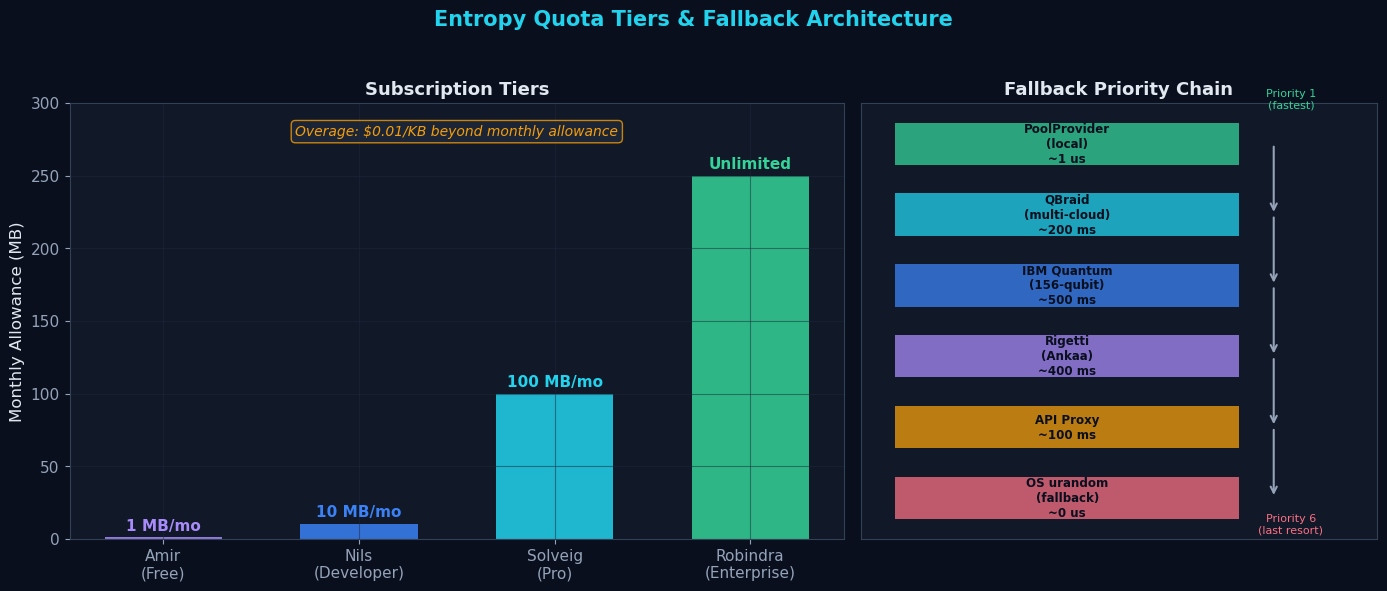


Entropy Quota Details:
Tier         Name            Allowance        Overage
-------------------------------------------------------
Free         Amir              1 MB/mo       $0.01/KB
Developer    Nils             10 MB/mo       $0.01/KB
Pro          Solveig         100 MB/mo       $0.01/KB
Enterprise   Robindra        Unlimited            N/A


In [9]:
# ── Quota tier visualization ──
tiers = ['Amir\n(Free)', 'Nils\n(Developer)', 'Solveig\n(Pro)', 'Robindra\n(Enterprise)']
allowances_mb = [1, 10, 100, 250]  # Enterprise shown as 250 for visual scale
colors = [ZM_VIOLET, ZM_BLUE, ZM_CYAN, ZM_EMERALD]
is_unlimited = [False, False, False, True]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [3, 2]})
fig.suptitle("Entropy Quota Tiers & Fallback Architecture",
             fontsize=15, fontweight='bold', color=ZM_CYAN)

# ── Left: Quota bar chart ──
bars = ax1.bar(tiers, allowances_mb, color=colors, alpha=0.85, edgecolor='none',
               width=0.6)

# Annotations
for i, (bar, mb, unlim) in enumerate(zip(bars, allowances_mb, is_unlimited)):
    label = "Unlimited" if unlim else f"{mb} MB/mo"
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
             label, ha='center', va='bottom', fontsize=11,
             fontweight='bold', color=colors[i])

# Cost annotation
ax1.text(0.5, 0.95, "Overage: $0.01/KB beyond monthly allowance",
         transform=ax1.transAxes, ha='center', va='top',
         fontsize=10, color=ZM_AMBER, style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e293b',
                   edgecolor=ZM_AMBER, alpha=0.8))

ax1.set_ylabel('Monthly Allowance (MB)', fontsize=12)
ax1.set_title('Subscription Tiers', fontsize=13)
ax1.set_ylim(0, 300)

# ── Right: Fallback chain (horizontal stacked) ──
providers = ['PoolProvider\n(local)', 'QBraid\n(multi-cloud)', 'IBM Quantum\n(156-qubit)',
             'Rigetti\n(Ankaa)', 'API Proxy', 'OS urandom\n(fallback)']
latencies = [0.001, 200, 500, 400, 100, 0.0001]  # ms
prov_colors = [ZM_EMERALD, ZM_CYAN, ZM_BLUE, ZM_VIOLET, ZM_AMBER, ZM_ROSE]

y_pos = np.arange(len(providers))[::-1]
ax2.barh(y_pos, [1]*len(providers), color=prov_colors, alpha=0.75,
         edgecolor='none', height=0.6)

for i, (prov, lat) in enumerate(zip(providers, latencies)):
    idx = len(providers) - 1 - i
    if lat >= 1:
        lat_str = f"~{lat:.0f} ms"
    else:
        lat_str = f"~{lat*1000:.0f} us"
    ax2.text(0.5, idx, f"{prov}\n{lat_str}",
             ha='center', va='center', fontsize=8.5,
             fontweight='bold', color='#0a0f1e')

# Priority arrow annotations
for i in range(len(providers) - 1):
    idx_from = len(providers) - 1 - i
    idx_to = len(providers) - 2 - i
    ax2.annotate('', xy=(1.1, idx_to), xytext=(1.1, idx_from),
                 arrowprops=dict(arrowstyle='->', color='#94a3b8',
                                 lw=1.5))

ax2.set_xlim(-0.1, 1.4)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('Fallback Priority Chain', fontsize=13)
ax2.text(1.15, len(providers) - 0.5, 'Priority 1\n(fastest)',
         ha='center', fontsize=8, color=ZM_EMERALD)
ax2.text(1.15, -0.5, 'Priority 6\n(last resort)',
         ha='center', fontsize=8, color=ZM_ROSE)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── Print tier details ──
print("\nEntropy Quota Details:")
print(f"{'Tier':<12} {'Name':<12} {'Allowance':>12} {'Overage':>14}")
print("-" * 55)
tier_data = [
    ("Free",       "Amir",     "1 MB/mo",    "$0.01/KB"),
    ("Developer",  "Nils",     "10 MB/mo",   "$0.01/KB"),
    ("Pro",        "Solveig",  "100 MB/mo",  "$0.01/KB"),
    ("Enterprise", "Robindra", "Unlimited",   "N/A"),
]
for tier, name, allow, overage in tier_data:
    print(f"{tier:<12} {name:<12} {allow:>12} {overage:>14}")

## 12. Summary: Why Quantum Entropy Matters for PQC

---

### Key Takeaways

**1. Randomness quality determines cryptographic strength.** The security of
ML-KEM-768 (FIPS 203) depends on the lattice problem being hard, but that
hardness assumption only holds when the secret key is sampled from a distribution
the adversary cannot predict. A predictable seed reduces a supposedly 192-bit
secure key to zero effective security.

**2. QRNG provides information-theoretic security.** Unlike CSPRNG, which relies
on computational hardness assumptions (assumptions that quantum computers can
weaken), QRNG randomness is guaranteed by quantum mechanics itself. No computational
advance, quantum or classical, can predict the outcome of a quantum measurement.

**3. The multi-provider architecture ensures resilience.** Zipminator's fallback
chain (Pool -> QBraid -> IBM -> Rigetti -> API -> OS) guarantees that entropy
is always available, with graceful degradation from quantum to CSPRNG when
necessary. The system never blocks, never fails, and logs every fallback event
for audit compliance (DORA Art. 7).

**4. Statistical verification builds trust.** The chi-squared, monobit, runs, and
autocorrelation tests demonstrated in this notebook are not just academic exercises.
They are the same tests required by NIST SP 800-22 for entropy source validation.
Running them regularly on production entropy provides continuous assurance that
the quantum hardware is functioning correctly.

**5. Entropy is a managed resource.** The quota system balances universal access
with operational sustainability. Free-tier users get enough quantum entropy for
personal key generation; enterprise users get unlimited access for high-volume
deployments. The pay-as-you-go overage model ensures no legitimate request is
ever denied.

---

**Next notebook:** [04 - Compliance & Regulatory Framework](04_compliance.ipynb)
covers DORA Art. 6-7 compliance, FIPS 203 verification, and audit trail
requirements for post-quantum cryptographic deployments.